In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../datasets/healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
columns_numeric = list(df.select_dtypes(exclude='object').columns)
columns_numeric.remove('stroke')
columns_numeric.remove('id')
columns_cat = list(df.select_dtypes(include='object').columns)

In [25]:
columns_numeric

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

In [26]:
columns_cat

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

(array([4861.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         249.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

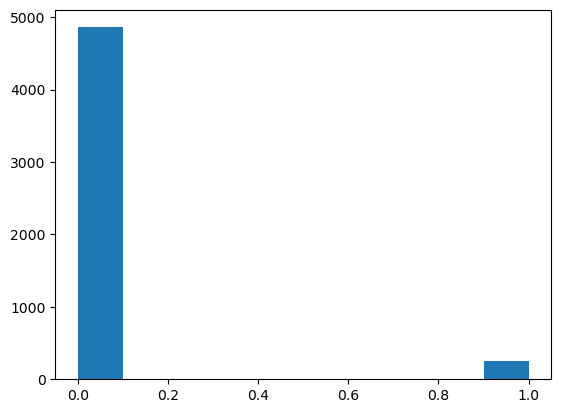

In [28]:
plt.hist(df['stroke'])

In [39]:
from sklearn.impute import SimpleImputer
imputer_num = SimpleImputer(strategy='median')
imputer_num.fit(df[columns_numeric])
df[columns_numeric] = imputer_num.transform(df[columns_numeric])

In [41]:
imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_cat.fit(df[columns_cat])
df[columns_cat]= imputer_cat.transform(df[columns_cat])

In [43]:
df.isna().sum().sum()

0

In [45]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoder.fit(df[columns_cat])
columns_encoded = list(encoder.get_feature_names_out())
df[columns_encoded] = encoder.transform(df[columns_cat])

In [47]:
df[columns_encoded]

,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5106,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5107,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [49]:
selected_columns = columns_numeric + columns_encoded
X = df[selected_columns]
y = df['stroke']

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=39)

In [53]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [55]:
model.score(X_test,y_test)

0.9561815336463224

In [57]:
yp = model.predict(X_test)

In [53]:
yp

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [59]:
from sklearn.ensemble import RandomForestClassifier
model_Rf = RandomForestClassifier()

In [61]:
model_Rf.fit(X_train,y_train)
model_Rf.score(X_test,y_test)

0.9546165884194053

In [63]:
import lime
import lime.lime_tabular

# Create the explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Stroke', 'Stroke'],
    mode='classification'
)


In [78]:
print(type(shap_values))         # should be a list
print(len(shap_values))          # should be 2
print(np.array(shap_values[0]).shape)  # shape: (num_samples, num_features)


<class 'numpy.ndarray'>
1278
(21, 2)


In [81]:
print(X_test.shape)  # Expecting: (1278, 21)


(1278, 21)


In [65]:
import numpy as np

# Pick an instance
i = 4
instance = X_test.iloc[i].values

# Explain prediction
exp = explainer.explain_instance(instance, model.predict_proba, num_features=10)

# Show explanation
exp.show_in_notebook(show_table=True)


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [75]:
exp.save_to_file('lime_explanation.html')


In [89]:
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [91]:

explainer = shap.TreeExplainer(model_Rf)
# Extract SHAP values for class 1
shap_class1 = shap_values[:, :, 1]  # shape becomes (1278, 21)

shap_values = explainer.shap_values(X_test)
shap_class1 = shap_values[:, :, 1]  # shape becomes (1278, 21)

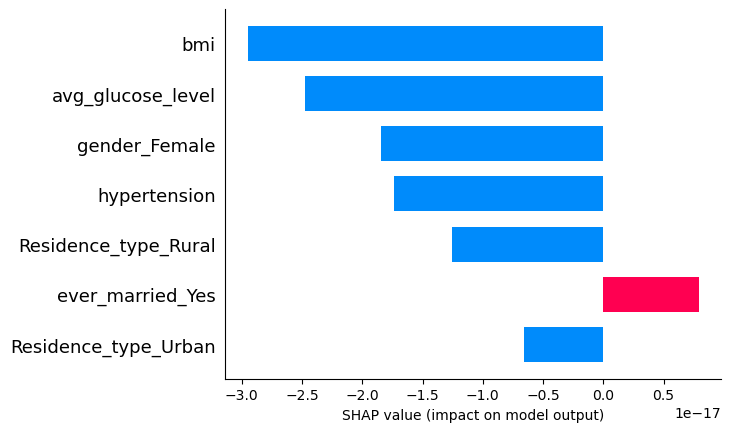

In [95]:
shap.bar_plot(shap_values[2].mean(1), feature_names=X_test.columns)


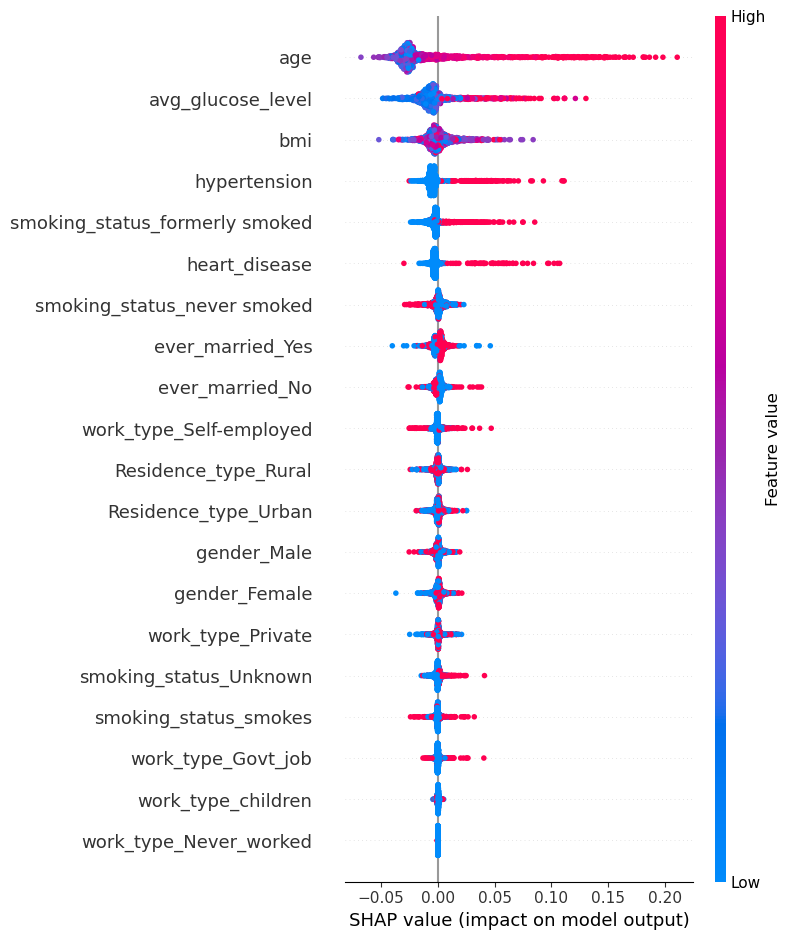

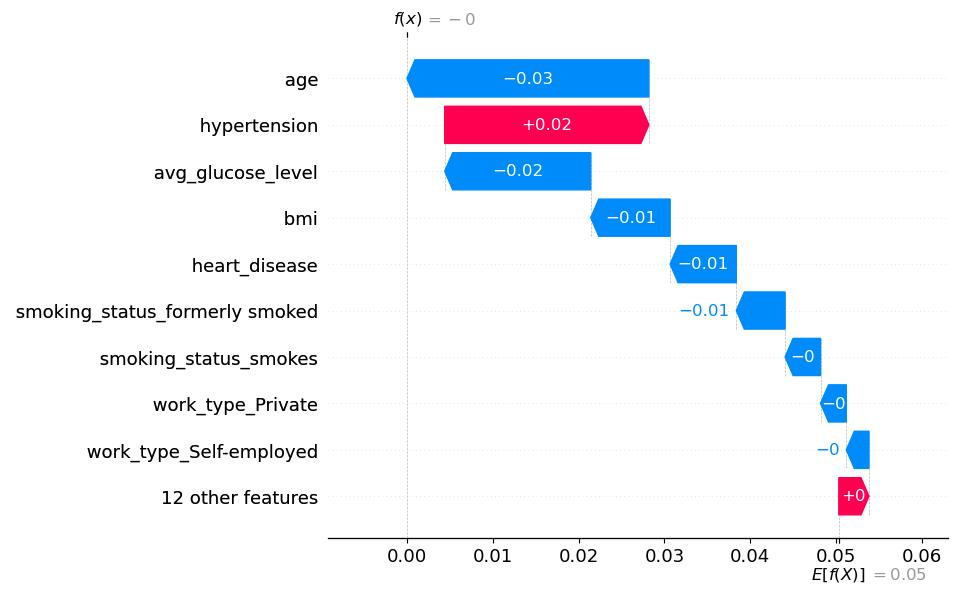

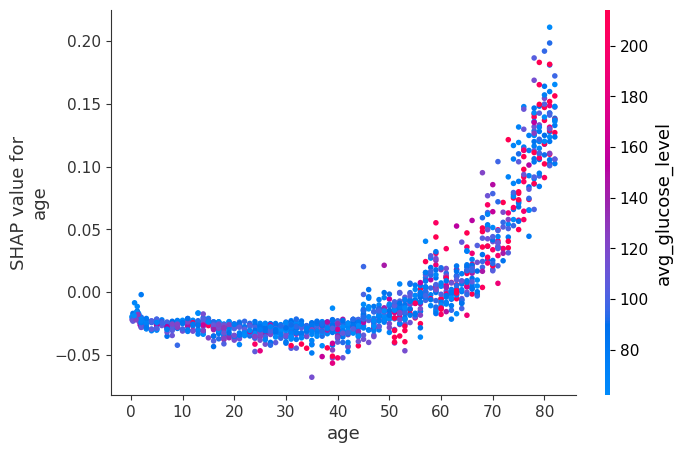

In [101]:
# Extract correct SHAP slice for stroke prediction
shap_class1 = shap_values[:, :, 1]

# Summary of feature impact
shap.summary_plot(shap_class1, X_test)

# Detailed explanation for patient at index 10
shap.force_plot(explainer.expected_value[1], shap_class1[10], X_test.iloc[10])
shap.plots._waterfall.waterfall_legacy(explainer.expected_value[1], shap_class1[10], X_test.iloc[10])

# Interaction for age
shap.dependence_plot("age", shap_class1, X_test)


In [103]:
import joblib
joblib.dump(model_Rf, 'stroke_model.pkl')


['stroke_model.pkl']

In [105]:
joblib.dump(X_train,'X_train.pkl')

['X_train.pkl']

In [107]:
joblib.dump(X_train,'X_test.pkl')

['X_test.pkl']

In [109]:
joblib.dump(explainer, 'shap_explainer.pkl')

['shap_explainer.pkl']

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Load model and SHAP explainer
model = joblib.load('stroke_model.pkl')
explainer = joblib.load('shap_explainer.pkl')

st.set_page_config(layout="wide")
st.title("🧠 Stroke Risk Predictor with Explainability")

# Sample feature input (adjust based on your model features)
def get_user_input():
    gender = st.selectbox("Gender", ["Male", "Female", "Other"])
    age = st.slider("Age", 0, 100, 50)
    hypertension = st.selectbox("Hypertension", ["No", "Yes"])
    heart_disease = st.selectbox("Heart Disease", ["No", "Yes"])
    ever_married = st.selectbox("Ever Married", ["No", "Yes"])
    work_type = st.selectbox("Work Type", ["Private", "Self-employed", "Govt_job", "children", "Never_worked"])
    residence_type = st.selectbox("Residence Type", ["Urban", "Rural"])
    avg_glucose_level = st.number_input("Average Glucose Level", 50.0, 300.0, 100.0)
    bmi = st.number_input("BMI", 10.0, 60.0, 25.0)
    smoking_status = st.selectbox("Smoking Status", ["never smoked", "formerly smoked", "smokes", "Unknown"])

    data = {
        "gender": gender,
        "age": age,
        "hypertension": 1 if hypertension == "Yes" else 0,
        "heart_disease": 1 if heart_disease == "Yes" else 0,
        "ever_married": ever_married,
        "work_type": work_type,
        "Residence_type": residence_type,
        "avg_glucose_level": avg_glucose_level,
        "bmi": bmi,
        "smoking_status": smoking_status
    }
    return pd.DataFrame([data])

input_df = get_user_input()

# Prediction
if st.button("Predict"):
    # Preprocess input (optional: one-hot encode or use pipeline)
    # input_df = pd.get_dummies(input_df)  # if you used get_dummies in training
    prediction = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0][1]

    st.subheader("📈 Prediction:")
    st.write(f"Predicted Class: {'Stroke Risk' if prediction == 1 else 'No Stroke Risk'}")
    st.write(f"Probability of Stroke: **{proba:.2%}**")

    # --- SHAP plots ---
    shap_values = explainer.shap_values(input_df)
    shap_vals_class1 = shap_values[:, :, 1]  # Class 1

    st.subheader("🔍 SHAP Summary Plot")
    fig1, ax1 = plt.subplots()
    shap.summary_plot(shap_vals_class1, input_df, plot_type="bar", show=False)
    st.pyplot(fig1)

    st.subheader("📊 SHAP Force Plot")
    shap.initjs()
    st_shap = st.components.v1.html(shap.force_plot(
        explainer.expected_value[1], shap_vals_class1[0], input_df.iloc[0], matplotlib=False
    ).html(), height=300)

    st.subheader("📉 SHAP Waterfall Plot")
    fig2, ax2 = plt.subplots()
    shap.plots._waterfall.waterfall_legacy(explainer.expected_value[1], shap_vals_class1[0], input_df.iloc[0], show=False)
    st.pyplot(fig2)

    st.subheader("⚡ SHAP Dependence Plot (age)")
    fig3, ax3 = plt.subplots()
    shap.dependence_plot("age", shap_vals_class1, input_df, show=False)
    st.pyplot(fig3)
